# Experiment 03 — PdO on HfO₂: initial DoE (LHS + simulated annealing)

This notebook produces the **first** space-filling design of experiments for **PdO on HfO₂**
(no data yet — we are at the design stage), and exports a fabrication-ready run sheet.

**Sampling method: LHS + simulated annealing (SA).** Each batch is a Latin Hypercube refined by
simulated annealing to minimize the *centered-L2 discrepancy* of the cumulative design. The choice
is justified in §3 against Sobol and plain LHS — under the real fabrication constraints LHS+SA
gives the best space-filling **and** the most independent factors, and it extends cleanly to later
batches.

**Why HfO₂ changes the bounds.** PdO on HfO₂ decomposes at ≥ ~510 °C (vs ~695 °C on Al₂O₃), so
both oxidation and vacuum-annealing temperatures are capped < 500 °C. Deposition temperature is
pinned at 425 °C, and oxidation pressure is restricted to the two practical setpoints.

**Factors (9 swept + 1 pinned):**

| # | Factor | Range | Resolution |
|---|---|---|---|
| 1 | Dep Power (W) | 2 → 40 | 1 W |
| 2 | O₂ Flow (sccm) | {0} ∪ 0.3 → 20 | 0.1 sccm |
| 3 | Dep Press (mTorr) | 2 → 10 | 0.1 mTorr |
| 4 | Ox Temp (°C) | 200 → 500 | 5 °C |
| 5 | Ox Press (atm) | {0.01, 0.02} | 2 levels |
| 6 | Ox Time (min) | 0 → 120 | 0.1 min |
| 7 | Vac Ann Temp (°C) | 25 → 500 | 5 °C |
| 8 | Vac Ann Time (min) | 0 → 120 | 0.1 min |
| 9 | Dep Thickness (nm) | 2 → 6 | 0.1 nm |
| 10 | Dep Temp (°C) | **pinned 425** | — |

Design size: **23 conditions × 3 replicates = 69 rows**. Outputs → `output/experiment03_hfo2_doe_design/`.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import qmc
from scipy.spatial.distance import pdist
import warnings; warnings.filterwarnings('ignore')

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)
OUT_DIR = 'output/experiment03_hfo2_doe_design'
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

GLOBAL_SEED, N_CONDITIONS, NUM_REPLICATES, DEP_TEMP_FIXED = 20, 23, 3, 425.0
print('Outputs ->', OUT_DIR)

Outputs -> output/experiment03_hfo2_doe_design


## 1. Factor configuration

`HFO2_CONFIG` defines the 9 swept factors (Dep Temp is appended later as a pinned constant).
`map_parameter` turns a unit-cube coordinate into a physical value, snapping to the tool
resolution (`step`), honoring the discrete *0 sccm* O₂ option (`gap`), and the 2 discrete Ox Press
levels. `normalise_for_metrics` does the inverse for quality scoring (physical → [0,1], discrete
levels → evenly spaced), so we can measure a design *as it will actually be fabricated*.

In [2]:
HFO2_CONFIG = {
    'Dep Power (W)':      {'min': 2.0,   'max': 40.0,  'step': 1.0},
    'O2 Flow (sccm)':     {'gap_prob': 0.10, 'gap_val': 0.0, 'min': 0.3, 'max': 20.0, 'step': 0.1},
    'Dep Press (mTorr)':  {'min': 2.0,   'max': 10.0,  'step': 0.1},
    'Ox Temp (°C)':       {'min': 200.0, 'max': 500.0, 'step': 5.0},
    'Ox Press (atm)':     [0.01, 0.02],
    'Ox Time (min)':      {'min': 0.0,   'max': 120.0, 'step': 0.1},
    'Vac Ann Temp (°C)':  {'min': 25.0,  'max': 500.0, 'step': 5.0},
    'Vac Ann Time (min)': {'min': 0.0,   'max': 120.0, 'step': 0.1},
    'Dep Thickness (nm)': {'min': 2.0,   'max': 6.0,   'step': 0.1},
}
FACTORS = list(HFO2_CONFIG.keys()); d = len(FACTORS)

def map_parameter(u, s):
    if isinstance(s, list):                                   # discrete levels (Ox Press)
        return s[min(int(u * len(s)), len(s) - 1)]
    if s.get('gap_prob', 0) > 0 and u < s['gap_prob']:        # discrete gap value (O2 = 0 sccm)
        return s['gap_val']
    if 'gap_prob' in s and s['gap_prob'] > 0:
        u = (u - s['gap_prob']) / (1 - s['gap_prob'])
    val = s['min'] + u * (s['max'] - s['min'])
    return round(round(val / s['step']) * s['step'], 4) if 'step' in s else round(val, 4)

def normalise_for_metrics(df_in, config):
    M = df_in[[c for c in df_in.columns if c in config]].astype(float).copy()
    for c in M.columns:
        s = config[c]
        if isinstance(s, list):
            uniq = sorted(set(s)); M[c] = M[c].map({v: (i/(len(uniq)-1) if len(uniq) > 1 else 0.0)
                                                    for i, v in enumerate(uniq)})
        else:
            M[c] = (M[c] - s['min']) / (s['max'] - s['min'])
    return np.clip(M.values, 0.0, 1.0)

def to_physical(U):
    return pd.DataFrame([[map_parameter(U[r, i], HFO2_CONFIG[FACTORS[i]]) for i in range(d)]
                         for r in range(len(U))], columns=FACTORS)
print(f'{d} swept factors + Dep Temp pinned at {DEP_TEMP_FIXED:g} °C')

9 swept factors + Dep Temp pinned at 425 °C


## 2. The LHS + SA sampler

A Latin Hypercube guarantees uniform 1-D marginals but not good joint coverage. We fix that with
simulated annealing: starting from a discrepancy-optimized LHS, repeatedly **swap two values
within one column** (which keeps the design a valid LHS) and accept the swap if it lowers the
centered-L2 discrepancy of the design — sometimes accepting a worse swap early on (high
temperature) to escape local minima, then cooling to a greedy finish.

The key feature is that the objective is the discrepancy of `[fixed; new]`: pass the
already-fabricated runs as `fixed` and SA places the **new** batch to fill their gaps, holding the
old points in place. For the initial batch `fixed` is empty, so it reduces to a plain optimized
LHS. One function therefore generates the first design *and* every future extension.

In [3]:
def optimized_lhs(n, dim, seed):
    """Discrepancy-optimized Latin Hypercube (scipy random-cd) — the SA starting design."""
    return qmc.LatinHypercube(d=dim, optimization='random-cd', seed=seed).random(n)

def _swap(P, col, a, b):
    P[[a, b], col] = P[[b, a], col]            # within-column swap -> stays a valid LHS

def conditional_sa_lhs(fixed, n_new, dim, seed, n_iter=12000, T_end=1e-3):
    """LHS + simulated annealing minimizing discrepancy of [fixed; new], `fixed` frozen.
    `fixed` may be an empty (0, dim) array for the initial batch. Returns the new batch (unit cube)."""
    rng = np.random.default_rng(seed)
    P = optimized_lhs(n_new, dim, seed)
    score = lambda: qmc.discrepancy(np.vstack([fixed, P]) if len(fixed) else P)
    cur = best = score(); best_P = P.copy()
    ups = []                                   # auto-scale start temperature to a typical uphill move
    for _ in range(200):
        c = rng.integers(dim); a, b = rng.choice(n_new, 2, replace=False)
        _swap(P, c, a, b); delta = score() - cur; _swap(P, c, a, b)
        if delta > 0: ups.append(delta)
    T = T0 = float(np.mean(ups)) if ups else 1e-3
    alpha = T_end ** (1.0 / n_iter)
    for _ in range(n_iter):
        c = rng.integers(dim); a, b = rng.choice(n_new, 2, replace=False)
        _swap(P, c, a, b); cand = score(); delta = cand - cur
        if delta < 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            cur = cand
            if cur < best: best, best_P = cur, P.copy()
        else:
            _swap(P, c, a, b)                  # reject -> revert
        T *= alpha                             # cool
    return best_P

## 3. Why LHS + SA? — justification vs Sobol and plain LHS

We compare three sequential-batch strategies over **5 batches of 23 conditions** (up to 115
cumulative points), and — crucially — evaluate **every method *as fabricated***: each design is
snapped to the resolution grid *including the 2-level Ox Press* before scoring, so all three live
under the identical real-world constraint and are truly comparable.

* **Sobol (fab)** — continue one Sobol sequence each batch.
* **Pure LHS (fab)** — a fresh plain Latin Hypercube each batch (no joint optimization).
* **LHS + SA (fab)** — `conditional_sa_lhs`, freezing all previously-fabricated runs.

Three metrics: **discrepancy** (coverage, lower better), **max |off-diagonal correlation|** (factor
independence, lower better), **min pairwise distance** (no near-duplicate runs, higher better).
Each point is the **mean over 4 random seeds** with **±1 std error bars** — the bars show the
seed-to-seed spread, so a single good design (like the exported one in §4) can land below its line,
especially for the noisy worst-pair correlation metric.

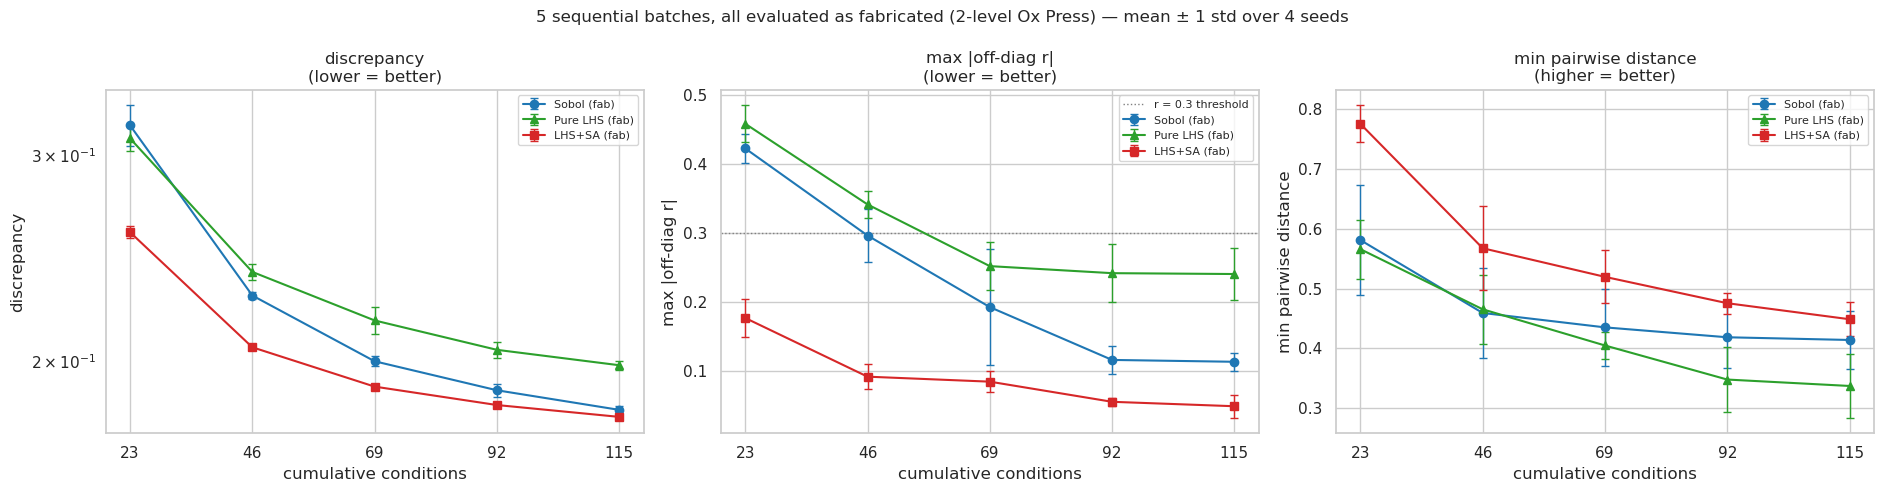

,cum_conditions,Sobol (fab) disc,Sobol (fab) maxr,Pure LHS (fab) disc,Pure LHS (fab) maxr,LHS+SA (fab) disc,LHS+SA (fab) maxr
0,23,0.3180,0.422,0.3100,0.458,0.2577,0.177
1,46,0.2275,0.296,0.2383,0.341,0.2055,0.092
2,69,0.1999,0.192,0.2166,0.252,0.1902,0.085
3,92,0.1888,0.116,0.2044,0.242,0.1834,0.055
4,115,0.1817,0.113,0.1983,0.240,0.1792,0.049


In [4]:
def _round_norm(U):                          # unit-cube design -> fabricated -> normalized [0,1]
    return normalise_for_metrics(to_physical(U), HFO2_CONFIG)
def _maxoff(P):
    C = np.corrcoef(P.T); np.fill_diagonal(C, 0.0); return np.abs(C).max()

NB_BATCHES, SEEDS = 5, 4
ns = [N_CONDITIONS * (k + 1) for k in range(NB_BATCHES)]
methods = ('Sobol (fab)', 'Pure LHS (fab)', 'LHS+SA (fab)')
M = {m: {q: np.zeros((SEEDS, NB_BATCHES)) for q in ('disc', 'maxr', 'mind')} for m in methods}

def _rec(store, si, k, Pnorm):
    store['disc'][si, k] = qmc.discrepancy(Pnorm)
    store['maxr'][si, k] = _maxoff(Pnorm)
    store['mind'][si, k] = pdist(Pnorm).min()

for si, seed in enumerate(range(SEEDS)):
    eng = qmc.Sobol(d=d, scramble=True, seed=seed)
    sob = np.empty((0, d)); plhs = np.empty((0, d)); sa = np.empty((0, d))
    for k in range(NB_BATCHES):
        sob  = np.vstack([sob,  eng.random(N_CONDITIONS)])
        plhs = np.vstack([plhs, qmc.LatinHypercube(d=d, seed=seed * 100 + k).random(N_CONDITIONS)])
        sa   = np.vstack([sa,   conditional_sa_lhs(sa, N_CONDITIONS, d, seed * 10 + k, n_iter=5000)])
        _rec(M['Sobol (fab)'], si, k, _round_norm(sob))
        _rec(M['Pure LHS (fab)'], si, k, _round_norm(plhs))
        _rec(M['LHS+SA (fab)'], si, k, _round_norm(sa))

cmp_tbl = pd.DataFrame({'cum_conditions': ns})
for m in methods:
    cmp_tbl[f'{m} disc'] = M[m]['disc'].mean(0).round(4)
    cmp_tbl[f'{m} maxr'] = M[m]['maxr'].mean(0).round(3)
cmp_tbl.to_excel(os.path.join(OUT_DIR, 'method_comparison.xlsx'), index=False)

styles = {'Sobol (fab)': ('o-', '#1f77b4'), 'Pure LHS (fab)': ('^-', '#2ca02c'),
          'LHS+SA (fab)': ('s-', '#d62728')}
panels = [('disc', 'discrepancy', 'lower = better', True),
          ('maxr', 'max |off-diag r|', 'lower = better', False),
          ('mind', 'min pairwise distance', 'higher = better', False)]
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a, (q, ylab, better, logy) in zip(ax, panels):
    for m, (ls, c) in styles.items():
        a.errorbar(ns, M[m][q].mean(0), yerr=M[m][q].std(0), fmt=ls, color=c, label=m,
                   capsize=3, markersize=6, elinewidth=1, capthick=1)
    if q == 'maxr': a.axhline(0.3, ls=':', color='gray', lw=1, label='r = 0.3 threshold')
    if logy: a.set_yscale('log')
    a.set_xlabel('cumulative conditions'); a.set_ylabel(ylab); a.set_title(f'{ylab}\n({better})')
    a.legend(fontsize=8); a.set_xticks(ns)
fig.suptitle('5 sequential batches, all evaluated as fabricated (2-level Ox Press) — '
             'mean ± 1 std over 4 seeds', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'method_comparison.png'), dpi=180, bbox_inches='tight')
plt.show()
cmp_tbl

**Decision.** Under the identical fabrication constraint, **LHS+SA wins on all three metrics at
every batch**: lowest discrepancy, decisively lowest correlation (it stays under the 0.3
confounding threshold while Sobol and pure LHS sit higher and never catch up at these sizes), and
the largest minimum spacing. All three discrepancies share the same raised floor set by the 2-level
Ox Press (a hard process constraint, identical for every method), so it does not change the
ranking. Sobol's theoretical low-discrepancy edge only appears at n ≈ 400+ — far beyond a realistic
campaign — and it never matches LHS+SA on factor independence, which is what most helps the
downstream GP/BO separate effects. **We therefore use LHS+SA for the sampling.**

## 4. The chosen design (23 conditions)

Generate the initial batch with `conditional_sa_lhs` (empty `fixed`), map to physical units, pin
Dep Temp at 425 °C, and expand to 3 replicates.

In [5]:
U = conditional_sa_lhs(np.empty((0, d)), N_CONDITIONS, d, GLOBAL_SEED, n_iter=12000)
design = to_physical(U)
design['Dep Temp (°C)'] = DEP_TEMP_FIXED
design.insert(0, 'Base_Run_ID', range(1, N_CONDITIONS + 1))
design['Batch'] = 'Batch 1'

design_full = design.loc[design.index.repeat(NUM_REPLICATES)].reset_index(drop=True)
design_full.insert(1, 'Replicate', design_full.groupby('Base_Run_ID').cumcount() + 1)

disc_design = qmc.discrepancy(normalise_for_metrics(design, HFO2_CONFIG))
print(f'{N_CONDITIONS} conditions x {NUM_REPLICATES} replicates = {len(design_full)} rows | '
      f'fabricated discrepancy = {disc_design:.4f}')
design.drop(columns='Batch')

23 conditions x 3 replicates = 69 rows | fabricated discrepancy = 0.2525


,Base_Run_ID,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C)
0,1,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0
1,2,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0
2,3,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0
3,4,37.0,16.6,6.3,355.0,0.01,88.3,75.0,9.9,2.5,425.0
4,5,23.0,7.0,9.4,435.0,0.01,95.7,410.0,98.9,3.4,425.0
5,6,21.0,0.9,3.3,435.0,0.02,73.7,205.0,49.0,2.2,425.0
6,7,10.0,8.0,2.9,280.0,0.01,56.6,430.0,12.4,5.8,425.0
7,8,27.0,17.5,2.0,475.0,0.01,61.4,300.0,36.6,3.9,425.0
8,9,4.0,15.5,5.9,390.0,0.02,43.6,390.0,112.4,3.0,425.0
9,10,19.0,3.0,6.6,260.0,0.01,71.7,90.0,30.8,5.4,425.0


## 5. Design diagnostics

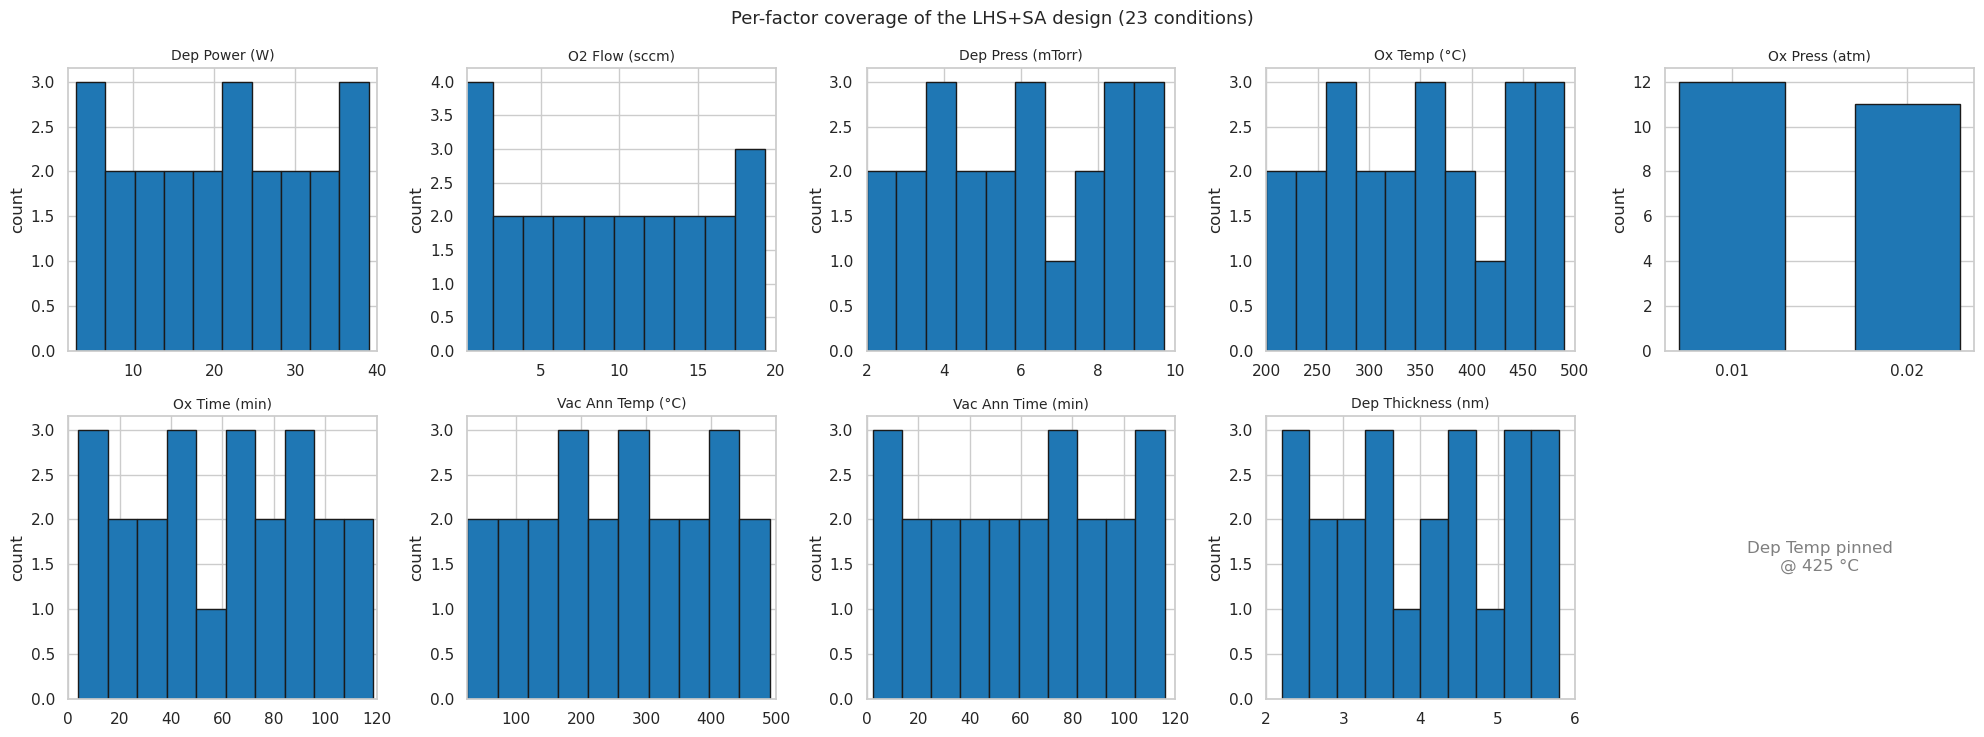

In [6]:
# Per-factor coverage (each factor should fill its range; discrete factors shown as level counts)
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
for ax, f in zip(axes.flat, FACTORS):
    s = HFO2_CONFIG[f]
    if isinstance(s, list):
        lv = sorted(s); ax.bar([str(x) for x in lv], [int((design[f] == x).sum()) for x in lv],
                               color='#1f77b4', edgecolor='k', width=0.6)
    else:
        ax.hist(design[f], bins=10, color='#1f77b4', edgecolor='k'); ax.set_xlim(s['min'], s['max'])
    ax.set_title(f, fontsize=10); ax.set_ylabel('count')
axes.flat[9].axis('off')
axes.flat[9].text(0.5, 0.5, f'Dep Temp pinned\n@ {DEP_TEMP_FIXED:g} °C', ha='center', va='center',
                  fontsize=12, color='gray')
fig.suptitle(f'Per-factor coverage of the LHS+SA design ({N_CONDITIONS} conditions)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'factor_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()

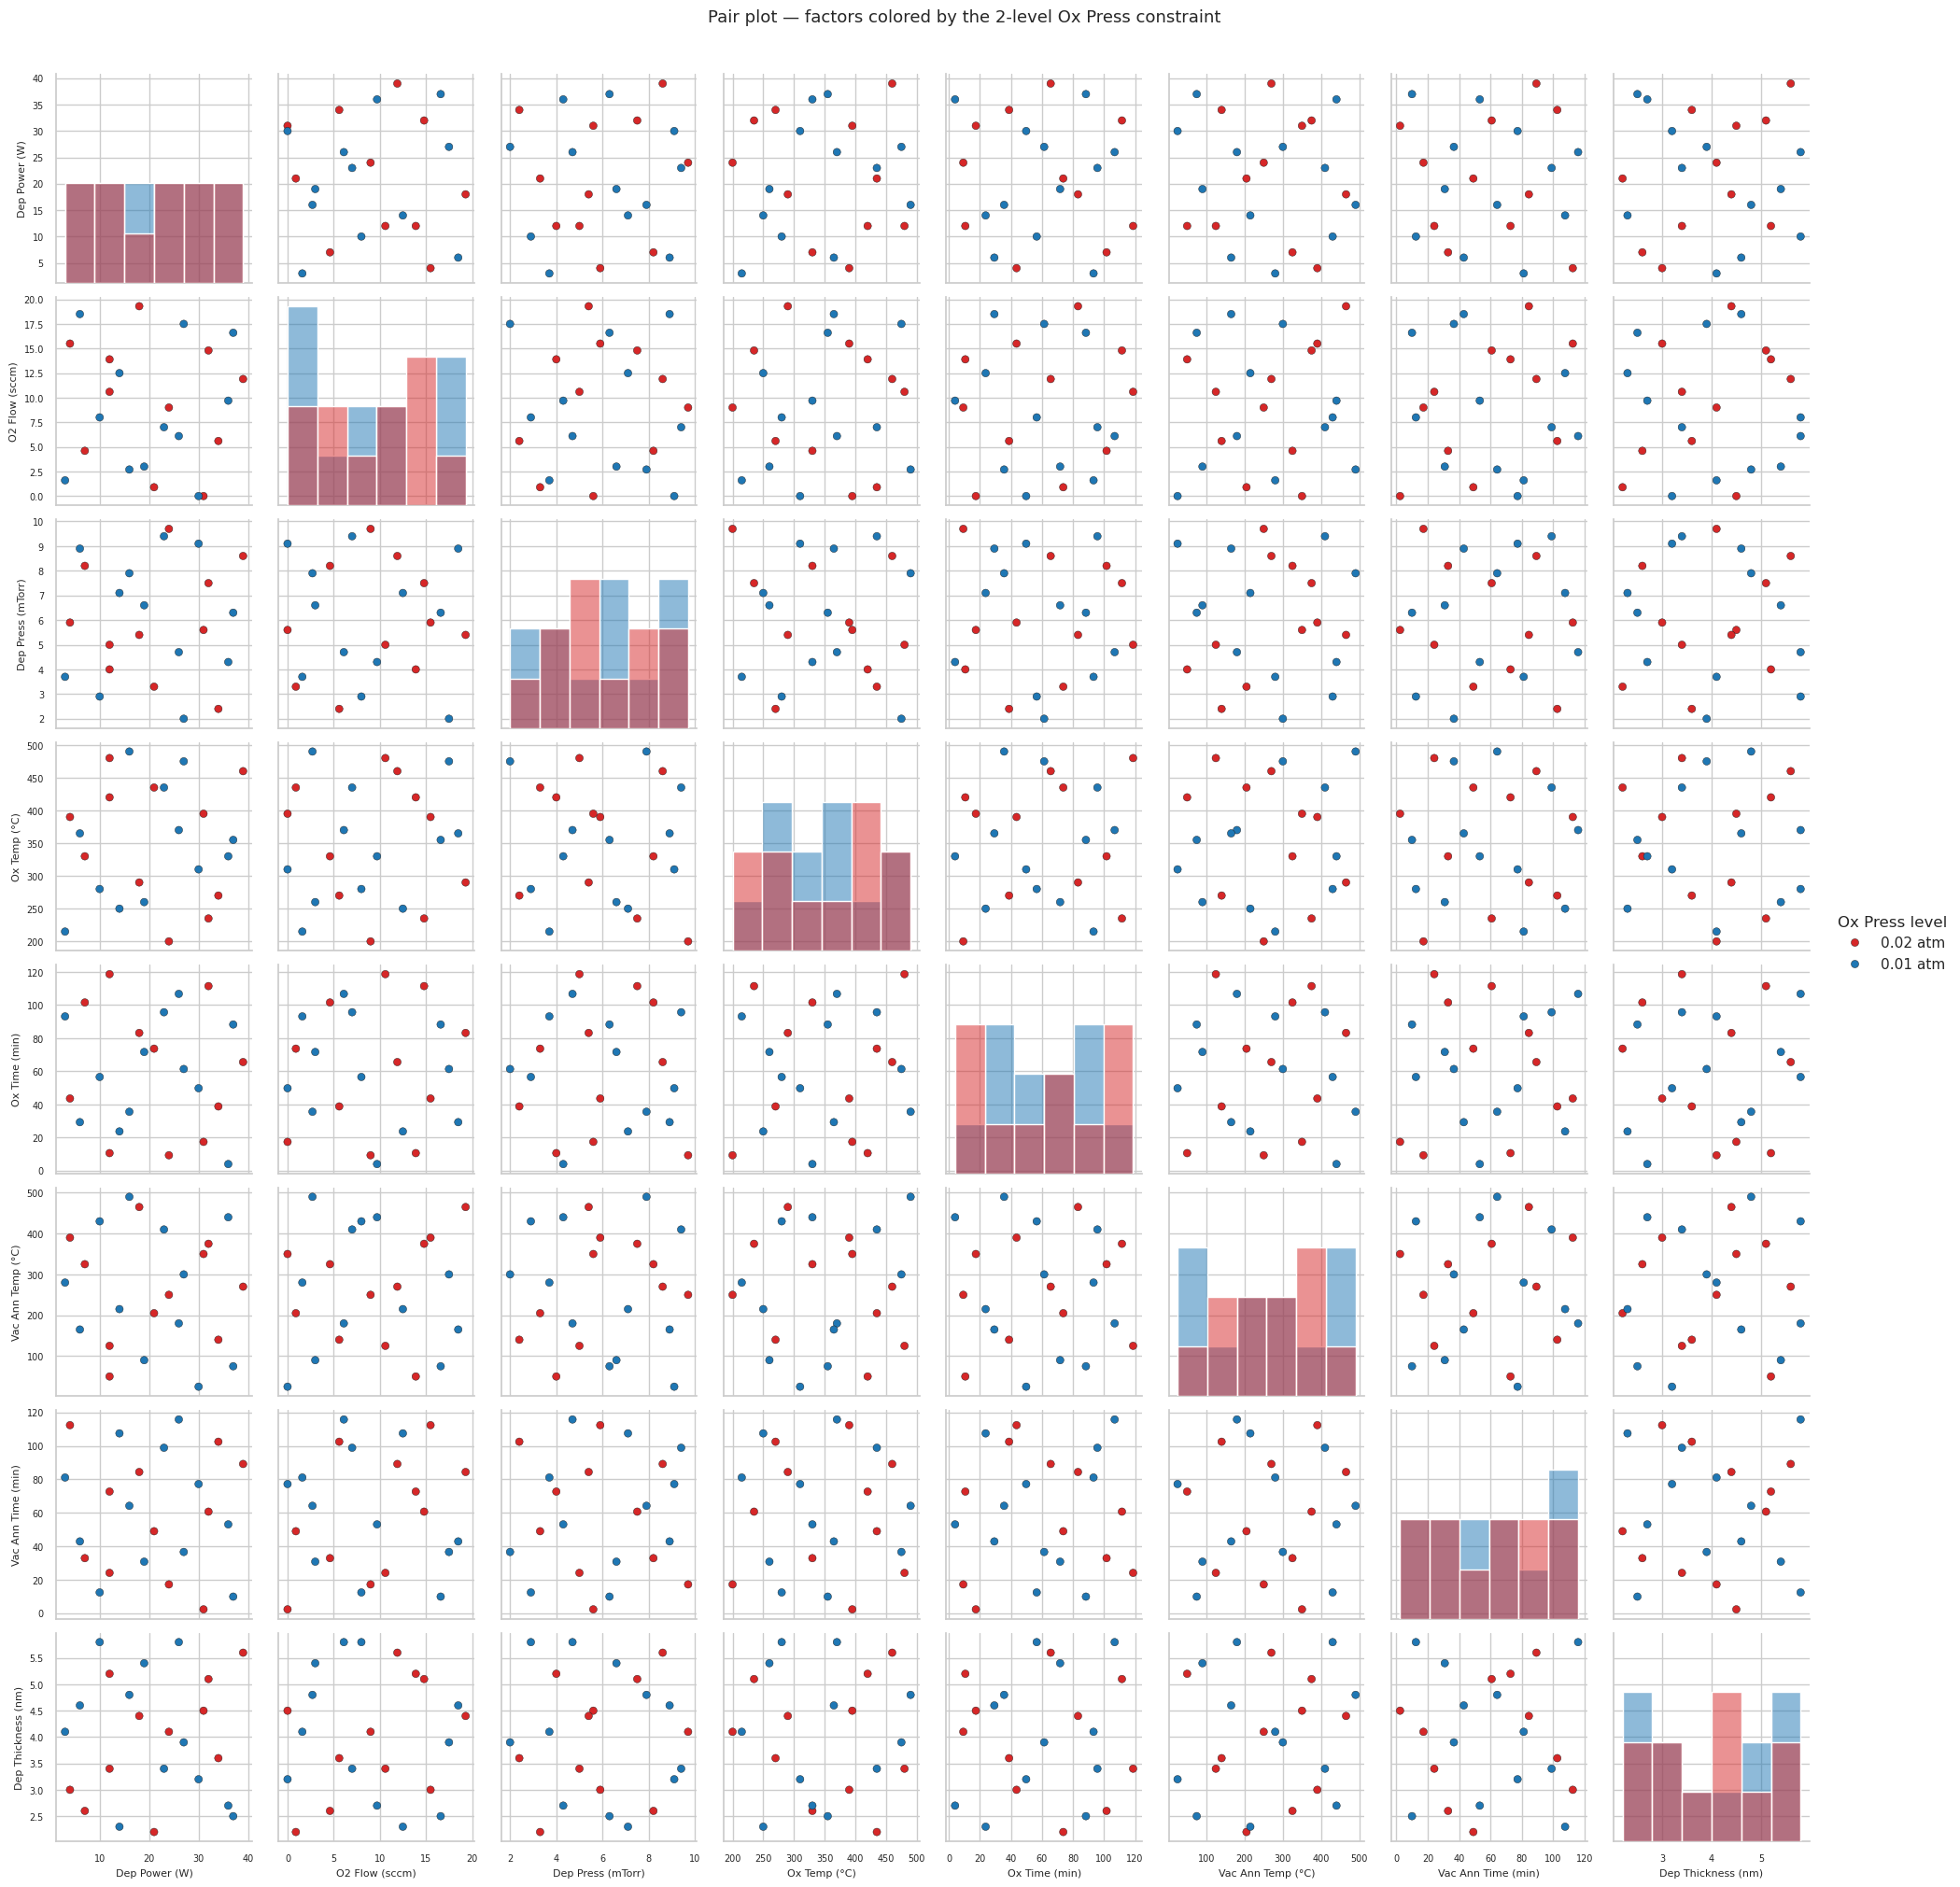

Ox Press split: {'0.01 atm': 12, '0.02 atm': 11}


In [7]:
# Pair plot colored by the 2-level Ox Press constraint
dfp = design.copy()
dfp['Ox Press level'] = dfp['Ox Press (atm)'].round(2).map({0.01: '0.01 atm', 0.02: '0.02 atm'})
other = [f for f in FACTORS if f != 'Ox Press (atm)']
g = sns.pairplot(dfp, vars=other, hue='Ox Press level', corner=False, diag_kind='hist',
                 palette={'0.01 atm': '#1f77b4', '0.02 atm': '#d62728'},
                 plot_kws=dict(s=34, edgecolor='k', linewidth=0.3))
g.fig.suptitle('Pair plot — factors colored by the 2-level Ox Press constraint', y=1.02, fontsize=13)
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=7); ax.xaxis.label.set_size(8); ax.yaxis.label.set_size(8)
g.savefig(os.path.join(OUT_DIR, 'pairplot_oxpress.png'), dpi=170, bbox_inches='tight')
plt.show()
print('Ox Press split:', dfp['Ox Press level'].value_counts().to_dict())

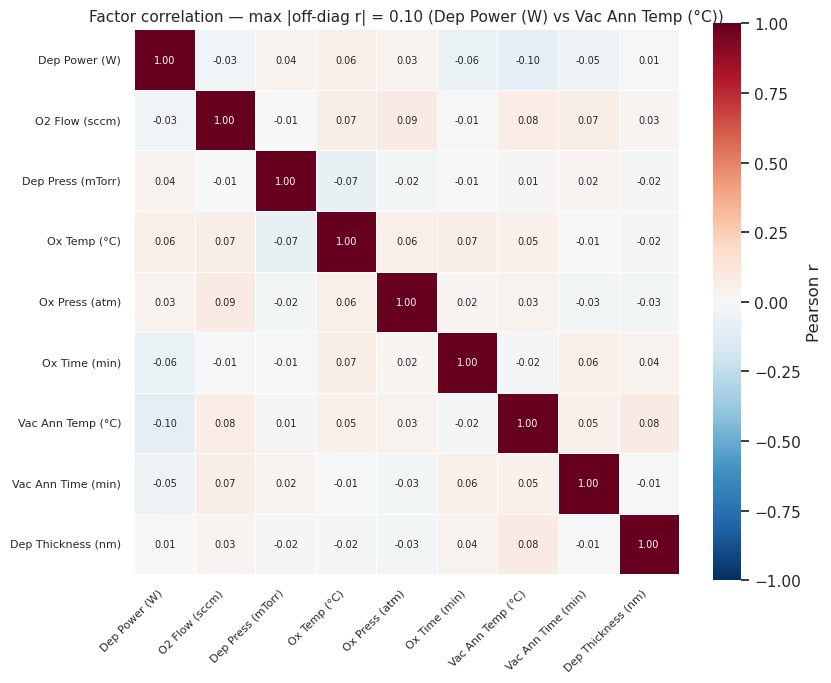

max |off-diagonal correlation| = 0.098  (well below the 0.3 confounding threshold)


In [8]:
# Correlation matrix (binary Ox Press included) — factor independence check
corr = design[FACTORS].corr()
off = corr.where(~np.eye(len(corr), dtype=bool)); mx = off.abs().max().max()
ip, jp = np.unravel_index(np.nanargmax(off.abs().values), off.shape)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title(f'Factor correlation — max |off-diag r| = {mx:.2f} ({FACTORS[ip]} vs {FACTORS[jp]})',
             fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'correlation_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'max |off-diagonal correlation| = {mx:.3f}  (well below the 0.3 confounding threshold)')

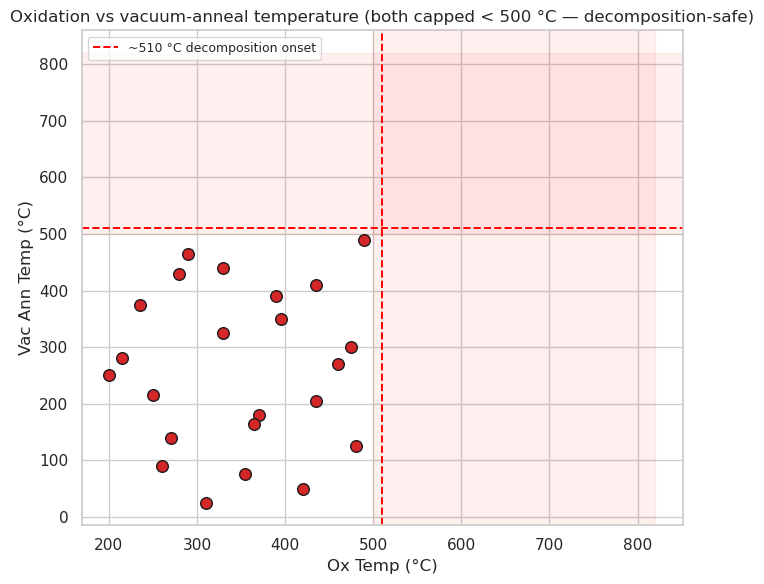

In [9]:
# Decomposition-safe temperature plane: both temperatures must stay < 500 °C
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(design['Ox Temp (°C)'], design['Vac Ann Temp (°C)'], c='#d62728', s=70,
           edgecolor='k', zorder=3)
ax.axvspan(500, 820, color='red', alpha=0.06); ax.axhspan(500, 820, color='red', alpha=0.06)
ax.axvline(510, ls='--', color='red', lw=1.4, label='~510 °C decomposition onset')
ax.axhline(510, ls='--', color='red', lw=1.4)
ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Oxidation vs vacuum-anneal temperature (both capped < 500 °C — decomposition-safe)')
ax.legend(loc='upper left', fontsize=9); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'temperature_plane.png'), dpi=200, bbox_inches='tight')
plt.show()

## 6. Extensibility — adding future batches

Choosing LHS+SA does **not** lock the campaign to 23 runs. For batch 2 (then 3, …), freeze the
already-fabricated runs and call `conditional_sa_lhs` again — it fills the gaps of *all* prior
points, regardless of how they were made. The check below shows a 3-batch build reaches the same
cumulative quality as designing all 69 points at once, so nothing is lost by going incrementally.

In [10]:
b1 = conditional_sa_lhs(np.empty((0, d)), N_CONDITIONS, d, 1, n_iter=6000)
b2 = conditional_sa_lhs(b1, N_CONDITIONS, d, 2, n_iter=6000)
b3 = conditional_sa_lhs(np.vstack([b1, b2]), N_CONDITIONS, d, 3, n_iter=6000)
fresh69 = optimized_lhs(3 * N_CONDITIONS, d, 0)
print('cumulative discrepancy (unit cube) as batches are added:')
print(f'  after batch 1 (23): {qmc.discrepancy(b1):.4f}')
print(f'  after batch 2 (46): {qmc.discrepancy(np.vstack([b1, b2])):.4f}')
print(f'  after batch 3 (69): {qmc.discrepancy(np.vstack([b1, b2, b3])):.4f}')
print(f'  [ref] fresh 69-pt optimized LHS designed at once: {qmc.discrepancy(fresh69):.4f}')

cumulative discrepancy (unit cube) as batches are added:
  after batch 1 (23): 0.0693
  after batch 2 (46): 0.0303
  after batch 3 (69): 0.0190
  [ref] fresh 69-pt optimized LHS designed at once: 0.0181


## 7. Export the fabrication design

In [11]:
out_path = os.path.join(OUT_DIR, 'PdO_HfO2_LHS_SA_design.xlsx')
cfg_rows = []
for f, s in HFO2_CONFIG.items():
    if isinstance(s, list):
        cfg_rows.append({'factor': f, 'min': min(s), 'max': max(s), 'step': '—', 'levels': str(s)})
    else:
        cfg_rows.append({'factor': f, 'min': s['min'], 'max': s['max'], 'step': s.get('step'),
                         'levels': f"gap_val={s['gap_val']} (p={s['gap_prob']})" if s.get('gap_prob') else '—'})
cfg_rows.append({'factor': 'Dep Temp (°C)', 'min': DEP_TEMP_FIXED, 'max': DEP_TEMP_FIXED,
                 'step': '—', 'levels': 'pinned'})
prov = pd.DataFrame([
    {'property': 'design method', 'value': 'LHS + simulated annealing (min cumulative discrepancy)'},
    {'property': 'n_conditions', 'value': N_CONDITIONS},
    {'property': 'replicates', 'value': NUM_REPLICATES},
    {'property': 'seed', 'value': GLOBAL_SEED},
    {'property': 'fabricated discrepancy', 'value': round(float(disc_design), 4)},
    {'property': 'max |off-diag correlation|', 'value': round(float(mx), 3)},
    {'property': 'extensible', 'value': 'yes — conditional_sa_lhs(freeze fabricated runs) for later batches'},
])
with pd.ExcelWriter(out_path) as w:
    design_full.to_excel(w, sheet_name='design_full',   index=False)
    design.to_excel(w,      sheet_name='design_unique', index=False)
    pd.DataFrame(cfg_rows).to_excel(w, sheet_name='config', index=False)
    prov.to_excel(w,        sheet_name='provenance',    index=False)
print('Saved:', out_path)
design_full.head(9)

Saved: output/experiment03_hfo2_doe_design/PdO_HfO2_LHS_SA_design.xlsx


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C),Batch
0,1,1,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0,Batch 1
1,1,2,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0,Batch 1
2,1,3,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0,Batch 1
3,2,1,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0,Batch 1
4,2,2,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0,Batch 1
5,2,3,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0,Batch 1
6,3,1,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0,Batch 1
7,3,2,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0,Batch 1
8,3,3,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0,Batch 1


## Output files

All under `output/experiment03_hfo2_doe_design/`:

* **`PdO_HfO2_LHS_SA_design.xlsx`** — the fabrication design (69-row run sheet + 23 unique conditions + config + provenance).
* `method_comparison.png` / `method_comparison.xlsx` — Sobol vs pure LHS vs LHS+SA (as fabricated), justifying the choice.
* `factor_distributions.png`, `pairplot_oxpress.png`, `correlation_matrix.png`, `temperature_plane.png` — design diagnostics.

**Next step (after fabrication returns data):** fit the GP surrogate and run multi-objective
Bayesian optimization (qLogNEHVI), then extend with batch 2 via `conditional_sa_lhs` freezing the
fabricated runs.